In [36]:
from pathlib import Path

from imagematerials.__main__ import export_summary_netcdf, simulate_stocks
from imagematerials.vehicles.preprocessing import (
    preprocessing,
)
from imagematerials.util import import_from_netcdf, export_to_netcdf
from imagematerials.model import GenericMainModel, GenericMaterials, GenericStocks
from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.concepts import vehicle_knowledge_graph

import prism


In [37]:
base_dir = "../data/raw"
prep_fp = Path("prep_vema.nc")

In [38]:
if not prep_fp.is_file():
    _, orig_prep_data = preprocessing(base_dir)
    export_to_netcdf(orig_prep_data, prep_fp)
prep_data = import_from_netcdf(prep_fp)
prep_data["weights"] = prep_data.pop("vehicle_weights")

In [69]:
import pandas as pd
from imagematerials.util import dataset_to_array

# Copy dimensiomns from material_fractions for xr_maintenance_material
materials = prep_data['material_fractions'].coords["material"]
types = prep_data['material_fractions'].coords["Type"]

maintenance_material_pd : pd.DataFrame = pd.read_csv(
    "../data/raw/vehicles/standard_data/all_vehicle_maintenance_image.csv", index_col=0)

stacked_maintenance_material = maintenance_material_pd.set_index("Type").stack().rename_axis(index=["Type", "material"]).reset_index(name="value")

stacked_maintenance_material = stacked_maintenance_material.set_index(["Type", "material"])

stacked_maintenance_material_xr = stacked_maintenance_material.to_xarray()
maintenance_material = dataset_to_array(stacked_maintenance_material_xr, ["Type", "materials"], [])


In [ ]:
import numpy as np
import xarray as xr
from scipy.stats import norm

# Define expected value of folded normal distribution
def expected_folded_norm(c, scale):
    term1 = np.sqrt(2 / np.pi) * np.exp(-c**2 / 2)
    term2 = c * (1 - 2 * norm.cdf(-c))
    return scale * (term1 + term2)

# Vectorized function to apply over the last axis (ScipyParam)
def compute_expected_lifetime(params):
    c = params[0]
    scale = params[1]
    return expected_folded_norm(c, scale)

selected_params = prep_data["lifetimes"]["folded_norm"].sel(Time=2020).drop("Time")

# Apply over the xarray DataArray
expected_lifetimes = xr.apply_ufunc(
    compute_expected_lifetime,
    selected_params,
    input_core_dims=[["ScipyParam"]],
    output_core_dims=[[]],
    vectorize=True,
    output_dtypes=[float]
)




C:\Users\5982758\AppData\Local\Temp\ipykernel_6524\1169275857.py:17: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  selected_params = prep_data["lifetimes"]["folded_norm"].sel(Time=2020).drop("Time")


In [ ]:
maintenance_material_per_year = (maintenance_material / expected_lifetimes)
maintenance_material_per_year_broadcasted = vehicle_knowledge_graph.rebroadcast_xarray_impute(
    maintenance_material_per_year, types.values)

prep_data["maintenance_material_fractions"] = maintenance_material_per_year_broadcasted

In [42]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [43]:
# Define the coordinates of all dimensions.
Region = list(prep_data["stocks"].coords["Region"].values)
Time = [t for t in complete_timeline]
Cohort = Time
Type = list(prep_data["stocks"].coords["Type"].values)
material = list(prep_data["material_fractions"].coords["material"].values)

# Create
main_model_normal = GenericMainModel(
    complete_timeline, Region=Region, Time=Time, Cohort=Cohort, Type=Type, prep_data=prep_data,
    compute_materials=True, compute_battery_materials=False, compute_maintenance_materials=True, 
    material=material)

In [44]:
main_model_normal.simulate(simulation_timeline)

In [45]:
main_model_factory = ModelFactory(
    prep_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

In [46]:
main_model_factory.simulate(simulation_timeline)

In [73]:
main_model_normal.stock_model.inflow[2020]

<xarray.DataArray (Type: 53, Region: 28)> Size: 12kB
array([[8.49103799e+04, 4.77945504e+04, 0.00000000e+00, ...,
        2.02629714e+05, 0.00000000e+00, 3.21364368e+06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.81986797e+05, 3.12917204e+05, 4.78686086e+05],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.54062701e-08, 3.71962490e-03, 2.09215067e-01],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.60841181e+01, 5.40236359e+01, ...,
        1.31599797e+01, 0.00000000e+00, 2.96800703e+01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.29473896e-01, 5.35796701e-02]])
Coordinates:
  * Type     (Type) <U35 7kB 'Bikes' 'Cars' ... 'Trains' 'Very Large Ships'
    Time     int64 8B 2020
  * Region   (Region) <U2 224B '1' '10' '11' '12' '13' ... '5' '6' '7' '8' '9'

In [60]:
main_model_normal.maintenance_model.inflow_maintenance[2020]

<xarray.DataArray (Region: 28, Type: 53, materials: 10)> Size: 119kB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.06454073e+04, 0.00000000e+00, 1.38249270e+04, ...,
         1.05313556e+04, 1.35945115e+05, 5.36506003e+03],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.86968381e+05, 0.00000000e+00, 1.00623151e+05, ...,
         7.66512680e+04, 9.89460985e+05, 3.90489763e+04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.06703185e+05, 0.00000000e+00, 8.68634031e+04, ...,
         6.61695635e+04, 8.54156797e+05, 3.37092104e+04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
    Time       int64 8B 2020
  * Region     (Region) <U2 224B '1' '10' '11' '12' '13' ... '5' '6' '7' '8' '9'
  * Type       (Type) <U35 7kB 'Bikes' 'Cars' ... 'Trains' 'Very Large Ships'
  * materials  (materials) object 80B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Wood'

In [64]:
main_model_normal.maintenance_model.inflow_maintenance[2020]

<xarray.DataArray (Region: 28, Type: 53, materials: 10)> Size: 119kB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.06454073e+04, 0.00000000e+00, 1.38249270e+04, ...,
         1.05313556e+04, 1.35945115e+05, 5.36506003e+03],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.86968381e+05, 0.00000000e+00, 1.00623151e+05, ...,
         7.66512680e+04, 9.89460985e+05, 3.90489763e+04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.06703185e+05, 0.00000000e+00, 8.68634031e+04, ...,
         6.61695635e+04, 8.54156797e+05, 3.37092104e+04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
    Time       int64 8B 2020
  * Region     (Region) <U2 224B '1' '10' '11' '12' '13' ... '5' '6' '7' '8' '9'
  * Type       (Type) <U35 7kB 'Bikes' 'Cars' ... 'Trains' 'Very Large Ships'
  * materials  (materials) object 80B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Wood'

In [ ]:
# Sum general inflow over Region
inflow_total = main_model_normal.material_model.inflow_materials[2020].sum(dim="Region")

# Sum maintenance inflow over Region and materials
inflow_maintenance = main_model_normal.maintenance_model.inflow_maintenance[2020].sum(dim=["Region"])#.sel(Type="Trains")

# Convert to pandas Series
inflow_total_pd = inflow_total.to_series()
inflow_maintenance_pd = inflow_maintenance.to_series()

# Combine into a DataFrame
df_plot = pd.DataFrame({
    "Total Inflow": inflow_total_pd,
    "Maintenance Inflow": inflow_maintenance_pd
})


AttributeError: 'TimeVariable' object has no attribute 'sum'

In [109]:
train_production = main_model_normal.material_model.inflow_materials[2010].sum(dim="Region").sum(dim="material").drop(["Time"])

train_maintenance = main_model_normal.maintenance_model.inflow_maintenance[2010].sum(dim="Region").sum(dim="materials").drop(["Time"])

inflow_total_pd = train_production.to_series()
inflow_maintenance_pd = train_maintenance.to_series()

# Combine into a DataFrame
df_plot = pd.DataFrame({
    "Total Inflow": inflow_total_pd,
    "Maintenance Inflow": inflow_maintenance_pd
})


C:\Users\5982758\AppData\Local\Temp\ipykernel_6524\2944271358.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  train_production = main_model_normal.material_model.inflow_materials[2010].sum(dim="Region").sum(dim="material").drop(["Time"])
C:\Users\5982758\AppData\Local\Temp\ipykernel_6524\2944271358.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  train_maintenance = main_model_normal.maintenance_model.inflow_maintenance[2010].sum(dim="Region").sum(dim="materials").drop(["Time"])


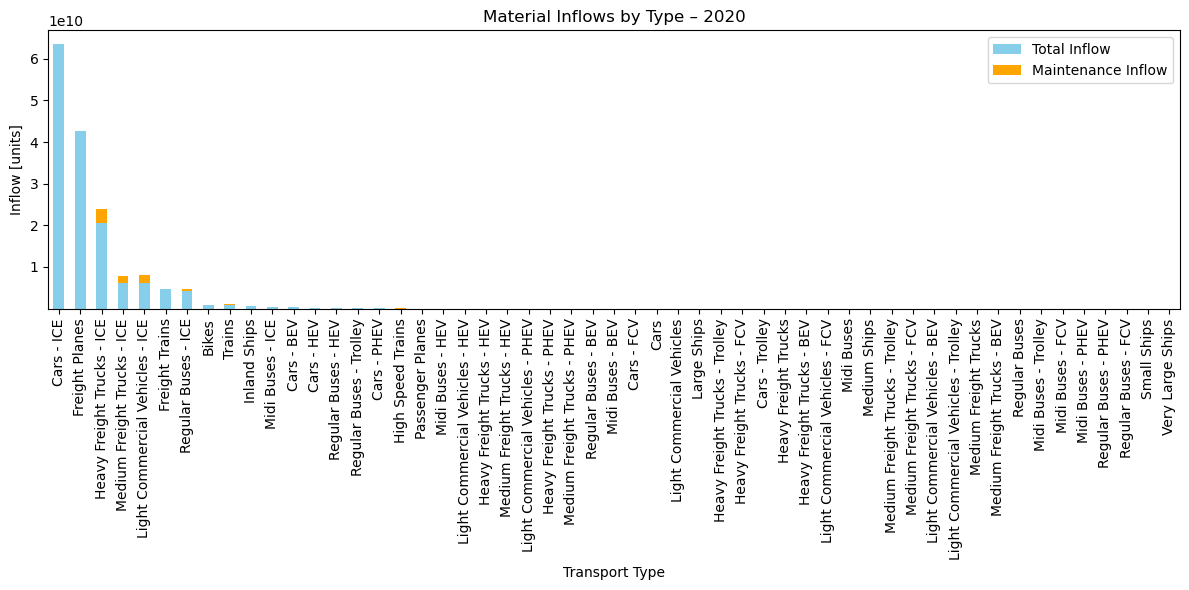

In [110]:
import matplotlib.pyplot as plt

# Sort by total inflow (optional)
df_plot = df_plot.sort_values("Total Inflow", ascending=False)

# Plot
ax = df_plot.plot(kind="bar", stacked=True, figsize=(12, 6), color=["skyblue", "orange"])
ax.set_ylabel("Inflow [units]")
ax.set_xlabel("Transport Type")
ax.set_title("Material Inflows by Type – 2020")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [89]:
train = main_model_normal.stock_model.inflow[2020].sum(dim="Region")##.
train.sel(Type="Trains")

<xarray.DataArray ()> Size: 8B
array(6384.19091534)
Coordinates:
    Type     <U35 140B 'Trains'
    Time     int64 8B 2020

In [90]:
main_model_normal.stock_model.inflow[2020]

<xarray.DataArray (Type: 53, Region: 28)> Size: 12kB
array([[8.49103799e+04, 4.77945504e+04, 0.00000000e+00, ...,
        2.02629714e+05, 0.00000000e+00, 3.21364368e+06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.81986797e+05, 3.12917204e+05, 4.78686086e+05],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.54062701e-08, 3.71962490e-03, 2.09215067e-01],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.60841181e+01, 5.40236359e+01, ...,
        1.31599797e+01, 0.00000000e+00, 2.96800703e+01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.29473896e-01, 5.35796701e-02]])
Coordinates:
  * Type     (Type) <U35 7kB 'Bikes' 'Cars' ... 'Trains' 'Very Large Ships'
    Time     int64 8B 2020
  * Region   (Region) <U2 224B '1' '10' '11' '12' '13' ... '5' '6' '7' '8' '9'

In [85]:
main_model_normal.maintenance_model.inflow_maintenance[2020].sum(dim=["Region"]).sel(Type="Trains")

<xarray.DataArray (materials: 10)> Size: 80B
array([1.40621032e+08, 0.00000000e+00, 2.41064627e+07, 1.29674143e+07,
       0.00000000e+00, 0.00000000e+00, 5.50161871e+07, 1.83634771e+07,
       2.37046883e+08, 9.35503095e+06])
Coordinates:
    Time       int64 8B 2020
    Type       <U35 140B 'Trains'
  * materials  (materials) object 80B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Wood'